# Drug Substance Manufacturing Process Optimization

This case study describes a configuration selection optimization problem (discrete) for a 
flowsheet optimization of a drug substance manufacturing process described in [1]. 
The optimized configuration can then be implemented in a flowsheet simulator to be 
further optimized on the operational level. 

The manufacturing process consists of 5 unit operations: reaction 1, reaction 2, vaporization, crystallization, and filtration. 
The model considers alternative unit selections for some unit operations: three choices 
for each reaction (PFR, CSTR, batch) and four choices for crystallization (1, 2, 3 
continuous MSMPR in series, batch). 

The integer programming model can be found in "discrete_ip/flst_opti_IP.py" script. The Pyomo model is converted to a quadratic unconstrained binary optimization (QUBO) through "discrete_ip/convert_to_qubo.jl" and imported in this script for solving via simulated annealing, quantum annealing, and entropy-based quantum computing. 

This script defines a QUBO model for the flowsheet optimization problem. The model is based on the flowsheet data provided in a csv file (see data/ssopt_gen_1.csv), also illustated in figures 1-2. The model includes binary decision variables for each flow in the network, and the objective is to minimize the total capital cost of the flowsheet. The model also includes disjunction constraints that enforces that flows at disjunctions cannot be active at the same time. Time-to-solution metrics are calculated and probability distribution of the solutions is plotted. 

References:

1. Daniel Casas-Orozco, Daniel J. Laky, Vivian Wang, Mesfin Abdi, Xin Feng, Erin Wood, Gintaras V. Reklaitis, and Zoltan K. Nagy. Techno-economic analysis of dynamic, end-to-end optimal pharmaceutical campaign manufacturing using pharmapy. *AIChE Journal*, **69**(9), 2023. ISSN 15475905. doi: 10.1002/aic.18142.

2. Daniel J. Laky, Daniel Casas-Orozco, Carl D. Laird, Gintaras V. Reklaitis, and Zoltan K. Nagy. Simulation-optimization framework for the digital design of pharmaceutical processes using pyomo and pharmapy. *Industrial and Engineering Chemistry Research*, **61**, 16128–16140, 2022. ISSN 15205045. https://pubs.acs.org/doi/abs/10.1021/acs.iecr.2c01636.

3. Barhate Y, Laky DJ, Casas-Orozco D, Reklaitis GV, Nagy ZK. Hybrid rule-based and optimization-driven framework for the synthesis of end-to-end optimal pharmaceutical processes. *AIChE J.*, 2025;e18888. doi:10.1002/aic.18888.


<figure>
    <img src="../images/ds_opt_flowsheet.jpg" alt="DS Optimization Flowsheet" style="width: 100%; max-width: 800px;"/>
    <figcaption>Figure 1: Superstructure flowsheet of drug substance manufacturing process.</figcaption>
</figure>

<figure>
    <img src="../images/ds_schematic.jpg" alt="DS Schematic" style="width: 100%; max-width: 800px;"/>
    <figcaption>Figure 2: Scehmatic drawing of the superstructure and variable assignments.</figcaption>
</figure>



In [1]:
# Import common functions (includes all necessary dependencies)
from ds_mfg_utils import *

# Import plotting functions
from ds_mfg_plotting import (
    plot_multibar_graph_discrete
)

# Data Collection

# Import QUBO model and solve using different methods

In [2]:
# Import Q matrix and scalars from the Julia export (QUBO model)
# The QUBO model is exported from "convert_to_qubo.jl" and "flowsheet_opti_simple.mps" from the Pyomo model built in "flowsheet_opti_simple.jl" using the ToQUBO package

Q_filepath = "./julia_exports/Q_matrix.csv"
L_filepath = "./julia_exports/L_vector.csv"
scalars_filepath = "./julia_exports/scalars.csv"

# Import the QUBO model from the Julia export
Q, beta = import_from_julia(scalars_filepath, Q_filepath, L_filepath)


In [ ]:
import os

# Set the D-Wave API token
os.environ["DWAVE_API_TOKEN"] = "your_dwave_api_token_here"

# =============== DWave / QA / Advantage 2 System ================ 
# Solve the QUBO model using Dwave quantum annealer (Advantage 2 system)
# Execution time includes embedding time + solving time 
DWaveSamples_zephyr, tts_qa_zephyr = solve_qa_dwave(Q, beta, save=True, topology="zephyr")


Execution time (QAnn):  0.14265727996826172
System name:  Advantage2_system1.8
{'timing': {'qpu_sampling_time': 139120.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 58.55, 'qpu_access_time': 173710.4, 'qpu_access_overhead_time': 2062.6, 'qpu_programming_time': 34590.4, 'qpu_delay_time_per_sample': 60.57, 'total_post_processing_time': 38.0, 'post_processing_overhead_time': 38.0}, 'problem_id': 'f93e6279-bc51-4ece-94cb-0d9adce83611', 'embedding_context': {'embedding': {1: (859, 3975), 0: (691,), 2: (3927, 847), 3: (3915, 3916), 4: (3867, 739), 5: (3903, 799), 6: (895, 3868), 7: (823,), 8: (3783,), 9: (3759, 786), 10: (775, 3879), 11: (751,), 12: (3819,), 13: (3806, 666), 14: (583,), 15: (3795, 642), 16: (618, 3747), 17: (594,), 18: (3686,), 19: (3699,), 20: (763,), 21: (3904,), 22: (727,), 23: (3830,), 24: (3844,), 25: (811,), 26: (3820,), 27: (3772, 906), 28: (907, 3892), 29: (787,), 30: (3855,), 31: (835,), 32: (715,), 33: (3734,), 34: (3782,), 35: (3771,)}, 'ch

In [ ]:
# ================ DWave neal / SA ==========================
simAnnSamples, t_sa = solve_sim_annealing(Q, beta, save=True)

# ================ DWave / QA ==========================
# Solve the QUBO model using Dwave quantum annealer 
# Execution time includes embedding time + solving time 
DWaveSamples, t_qa = solve_qa_dwave(Q, beta, save=True)

# ================ QCI dirac-1 / EQC ==========================
# Solve the QUBO model using QCI dirac-1 / EQC 
file_name = "flowsheet_opti.json"
qci_df, t_qci = solve_eqc_qci(Q, beta, file_name, num_sample=100)

# Use a function to extract energy and probability data only and convert to dataframe
qa_df = sampleset_to_df(DWaveSamples)
sa_df = sampleset_to_df(simAnnSamples)

df_names = ['DWave_QA','SimAnnealing', 'QCI_EQC']
df_list = [qa_df, sa_df, qci_df]

# Import Data for Analysis 
Use this section to import previous data. If data was collected in Data Collection, this step is not necessary. 

In [3]:
import os
import json

import_dir = './result_raw'

sa_path = os.path.join(import_dir, 'SA_results_20250819_163847.json')
qa_path = os.path.join(import_dir, 'Dwave_QA_results_1_20250819_114708.json')
qa_adv2_path = os.path.join(import_dir, 'Dwave_QA_results_20251121_170656.json')
qci_path = os.path.join(import_dir, 'QCI_EQC_results.json')

sa_df, t_sa = import_sampleset(sa_path)
(qa_df, t_qa), t_qa_qpu = import_sampleset(qa_path, qa=True)    # t_qa_qpu is quantum time, t_qa is total execution time
(qa_adv2_df, t_adv2_qa), t_adv2_qa_qpu = import_sampleset(qa_adv2_path, qa=True)    # t_qa_qpu is quantum time, t_qa is total execution time
qci_df, t_qci = import_sampleset(qci_path)


# Data Analysis

These results may be collected from Data Collection section or imported from saved files. 

In [4]:
# ================ Data Analysis ================
df_list = [qa_df, qa_adv2_df, sa_df, qci_df]
df_names = ['DWave_QA','DWave_QA_adv2', 'SimAnnealing', 'QCI_EQC']

# ========== Calculate time-to-solution (tts) ==========
feas_ub = 23        # upper bound for feasible solution, taken from Gurobi result
opt_ub = 11.8       # upper bound for optimal solution, taken from Gurobi result

# Calculate the time to solution for the feasible solutions (tts_f) and optimal solutions (tts_opt)
sa_tts_f = calculate_tts(sa_df, t_sa, feas_ub)
sa_tts_opt = calculate_tts(sa_df, t_sa, opt_ub)
qci_tts_f = calculate_tts(qci_df, t_qci, feas_ub)
qci_tts_opt = calculate_tts(qci_df, t_qci, opt_ub)
dwave_total_tts_f = calculate_tts(qa_df, t_qa, feas_ub)
dwave_total_tts_opt = calculate_tts(qa_df, t_qa, opt_ub)
dwave_qc_tts_f = calculate_tts(qa_df, t_qa_qpu, feas_ub)
dwave_qc_tts_opt = calculate_tts(qa_df, t_qa_qpu, opt_ub)

dwave_adv2_total_tts_f = calculate_tts(qa_adv2_df, t_adv2_qa, feas_ub)
dwave_adv2_total_tts_opt = calculate_tts(qa_adv2_df, t_adv2_qa, opt_ub)
dwave_adv2_qc_tts_f = calculate_tts(qa_adv2_df, t_adv2_qa_qpu, feas_ub)
dwave_adv2_qc_tts_opt = calculate_tts(qa_adv2_df, t_adv2_qa_qpu, opt_ub)

tts_feas = {
    'SA': sa_tts_f, 
    'QA-DWAVE_qpu': dwave_qc_tts_f, 
    'QA-DWAVE_total': dwave_total_tts_f, 
    'QA-DWAVE_adv2_qpu': dwave_adv2_qc_tts_f, 
    'QA-DWAVE_adv2_total': dwave_adv2_total_tts_f, 
    'EQC-QCI_qpu': qci_tts_f
    }
tts_opt = {
    'SA': sa_tts_opt, 
    'QA-DWAVE_qpu': dwave_qc_tts_opt, 
    'QA-DWAVE_total': dwave_total_tts_opt, 
    'QA-DWAVE_adv2_qpu': dwave_adv2_qc_tts_opt, 
    'QA-DWAVE_adv2_total': dwave_adv2_total_tts_opt, 
    'EQC-QCI_qpu': qci_tts_opt
    }

# Format each value to 1 decimal place
formatted_tts_feas = {k: f"{v:.2f}" for k, v in tts_feas.items()}
formatted_tts_opt = {k: f"{v:.2f}" for k, v in tts_opt.items()}

df_tts = pd.DataFrame({
    'TTS_feas': formatted_tts_feas,
    'TTS_opt': formatted_tts_opt
})
print(df_tts)

Probability of solution <= 23 : 0.918
Time to solution <= 23 : 1.1050396487165544
Probability of solution <= 11.8 : 0.01
Time to solution <= 11.8 : 274.99021109370307
Probability of solution <= 23 : 1.0
Time to solution <= 23 : 35
Probability of solution <= 11.8 : 0.42
Time to solution <= 11.8 : 295.89299703818807
Probability of solution <= 23 : 0.088
Time to solution <= 23 : 69.5102758941456
Probability of solution <= 11.8 : 0.002
Time to solution <= 11.8 : 3198.27702522385
Probability of solution <= 23 : 0.088
Time to solution <= 23 : 6.379314801801583
Probability of solution <= 11.8 : 0.002
Time to solution <= 11.8 : 293.52229875109504
Probability of solution <= 23 : 0.835
Time to solution <= 23 : 0.36461176461089273
Probability of solution <= 11.8 : 0.004
Time to solution <= 11.8 : 163.91156317863235
Probability of solution <= 23 : 0.835
Time to solution <= 23 : 0.4439791329917068
Probability of solution <= 11.8 : 0.004
Time to solution <= 11.8 : 199.5912386014943
                 

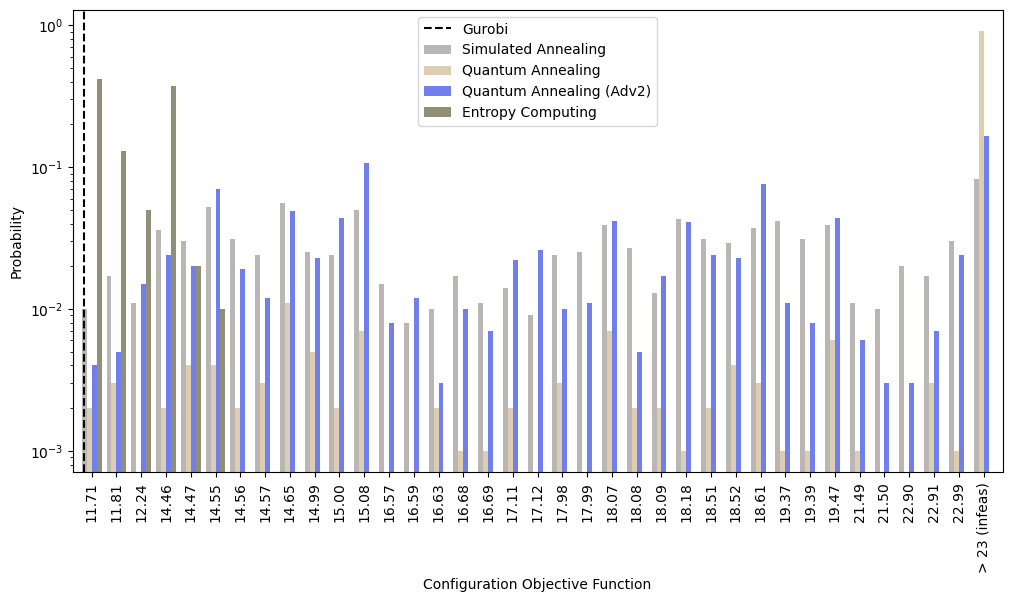

In [5]:
# ========== Plot the results of the optimization ==========
# combine the probability values that have energy values (infeasible solutions) that are > feas_ub to one value
simAnn_df_red = sum_infeas_soln(sa_df, feas_ub)
dwave_df_red = sum_infeas_soln(qa_df, feas_ub)
dwave_adv2_df_red = sum_infeas_soln(qa_adv2_df, feas_ub)

# Add the Gurobi results to the graph 
gurobi_result = sa_df.index[0]

df_list = [simAnn_df_red, dwave_df_red, dwave_adv2_df_red, qci_df] 
df_names = ['Simulated Annealing', 'Quantum Annealing','Quantum Annealing (Adv2)', 'Entropy Computing'] 
df_colors = [ '#9d9795', '#cfb991', "#3547e7", '#646040'] 

plot_multibar_graph_discrete(df_list, df_names, df_colors, feas_ub, vertical_line=gurobi_result)

In [6]:
# ========== Compare Energy Levels Across Dataframes ==========
from ds_mfg_helper_fn import compare_dataframe_energy_levels

# Prepare dataframes and names
df_list_feas = [simAnn_df_red, dwave_df_red, dwave_adv2_df_red, qci_df]
df_names_feas = ['SA', 'QA_adv1', 'QA_adv2', 'QCI']

# Compare energy levels (rounding to 2 decimals, same as plotting function)
comparison_results = compare_dataframe_energy_levels(
    df_list_feas, 
    df_names_feas, 
    round_decimals=2,
    energy_threshold=feas_ub,  # Only consider feasible solutions
    display=True
)


ENERGY LEVEL COMPARISON SUMMARY

Summary Statistics:
Dataframe  Total_Energy_Levels  Unique_Energy_Levels  Missing_Energy_Levels  Min_Energy  Max_Energy  Best_Energy
       SA                   36                     0                      0       11.71       22.99        11.71
  QA_adv1                   29                     0                      7       11.71       22.99        11.71
  QA_adv2                   36                     0                      0       11.71       22.99        11.71
      QCI                    6                     0                     30       11.71       14.55        11.71

MISSING ENERGY LEVELS BY DATAFRAME

SA - No missing energy levels (contains all energy levels from other dataframes)

QA_adv1 - Missing 7 energy level(s):
  12.24 (found in: SA, QA_adv2, QCI)
  16.57 (found in: SA, QA_adv2)
  16.59 (found in: SA, QA_adv2)
  17.12 (found in: SA, QA_adv2)
  17.99 (found in: SA, QA_adv2)
  21.50 (found in: SA, QA_adv2)
  22.90 (found in: SA, QA_adv

In [7]:
# ================ Measure Embedding Times ==========================
# Import the helper function for measuring embedding times
from ds_mfg_helper_fn import measure_embedding_times_for_samplers

# Measure embedding time for different topologies
# Example: measure for pegasus topology (Advantage 4.1)
embedding_result_pegasus = measure_embedding_times_for_samplers(Q, beta, "pegasus", trials=30)
print("Pegasus (Advantage 4.1) embedding time:", embedding_result_pegasus)

# Example: measure for zephyr topology (Advantage 2)
embedding_result_zephyr = measure_embedding_times_for_samplers(Q, beta, "zephyr", trials=30)
print("Zephyr (Advantage 2) embedding time:", embedding_result_zephyr)

Pegasus (Advantage 4.1) embedding time: {'trials': 30, 'successes': 30, 'failures': 0, 'median_s': 0.09377821599628078, 'p90_s': 0.12398384099651594, 'min_s': 0.06821587299054954, 'max_s': 0.13231777200417127}
Zephyr (Advantage 2) embedding time: {'trials': 30, 'successes': 30, 'failures': 0, 'median_s': 0.0864902089961106, 'p90_s': 0.10546653800702188, 'min_s': 0.06336717199883424, 'max_s': 0.13940135099983308}
